In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("C:\\Users\\singh\\OneDrive\\Desktop\\fullstack\\Project1\\HR Employee Attrition Data.csv.csv")
print(df.shape)
print(df["Attrition"].value_counts(normalize=True))

(1470, 35)
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


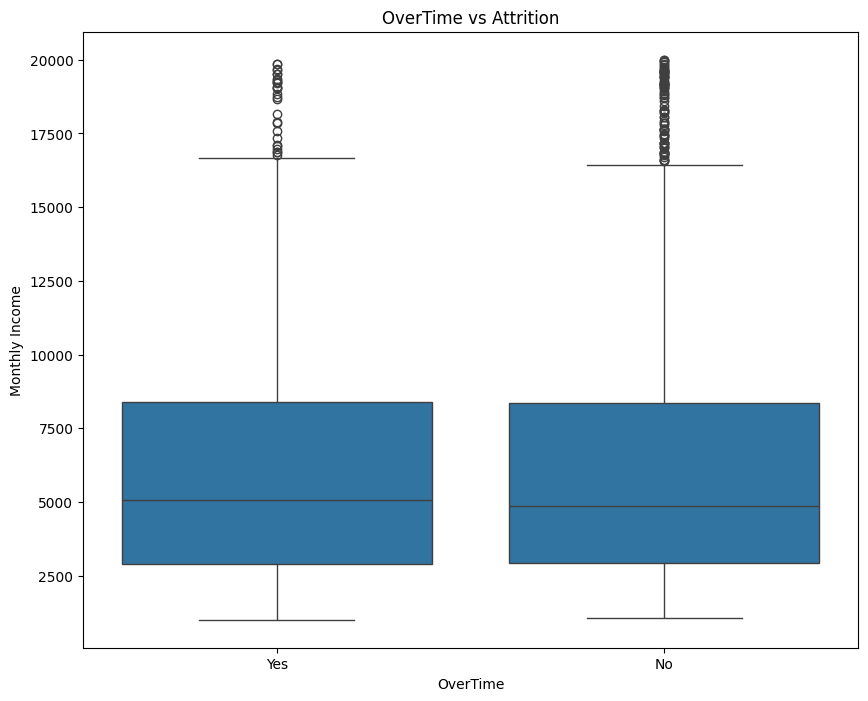

In [ ]:
#Incomee vs Attrition
plt.figure(figsize=(10, 8))
sns.boxplot(x="OverTime", y="MonthlyIncome", data=df)
plt.title("OverTime vs Attrition")
plt.xlabel("OverTime")
plt.ylabel("Monthly Income")
plt.show()

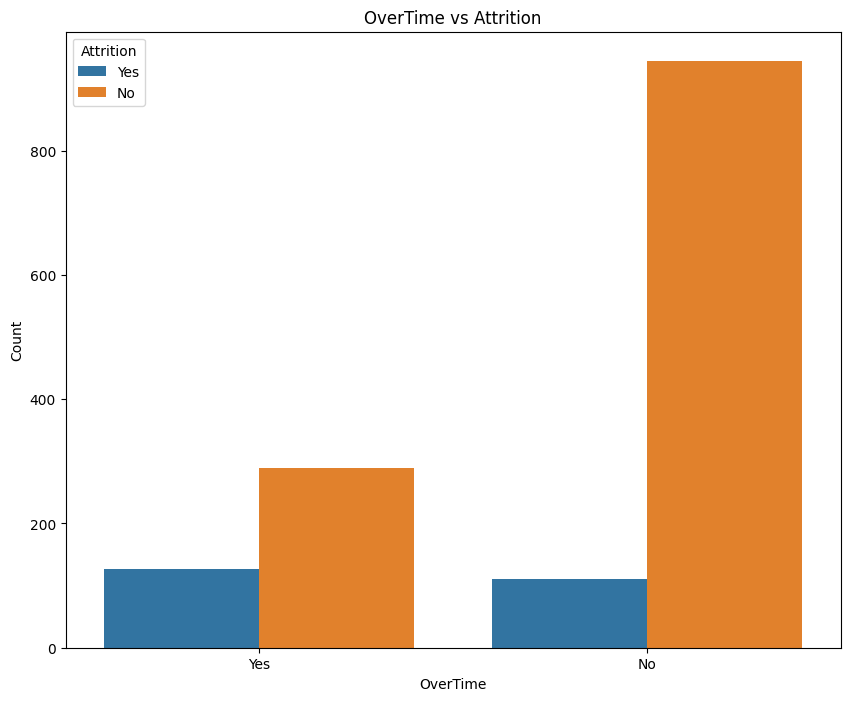

In [ ]:
#OverTime vs Attrition
plt.figure(figsize=(10, 8))
sns.countplot(x="OverTime", hue="Attrition", data=df)
plt.title("OverTime vs Attrition")
plt.xlabel("OverTime")
plt.ylabel("Count")
plt.legend(title="Attrition")
plt.show()

Step 3 : Data preprocessing

In [ ]:
# Drop irrelevant columns
df.drop(["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"], axis=1, inplace=True)
#df.info()

# Encode categorical variables
encoder = {}
for col in df.select_dtypes(include=["object"]).columns:
    lb = LabelEncoder()
    df[col] = lb.fit_transform(df[col])
    encoder[col] = lb
    
# Split data into features and target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

step 4: Modeling and Tunning

In [ ]:
#Define the model
rf = RandomForestClassifier(random_state=42)
# Hyperparameter tuning
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)


Step 5: Saving the Model

In [ ]:
model = RandomForestClassifier(**grid_search.best_params_, random_state=42)
model.fit(X, y)

# Save the model
joblib.dump(model, "employee_attrition_model.pkl")
joblib.dump(lb, "label_encoder.pkl")
joblib.dump(X.columns.to_list(), "feature_columns.pkl")

['feature_columns.pkl']

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.71      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.80      0.56      0.58       294
weighted avg       0.86      0.88      0.84       294

[[253   2]
 [ 34   5]]


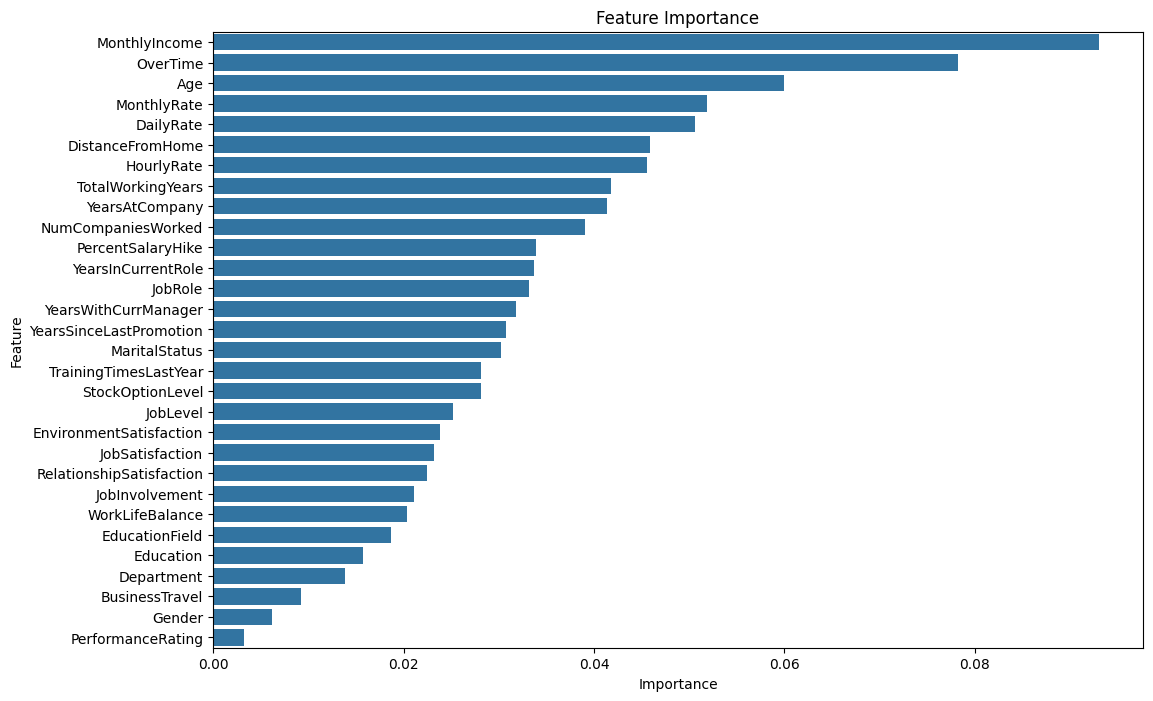

In [ ]:
best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))
importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
model = RandomForestClassifier(**grid_search.best_params_, random_state=42)
model.fit(X, y)

# Save the model
joblib.dump(model, "employee_attrition_model.pkl")
joblib.dump(encoder, "label_encoder.pkl")
joblib.dump(X.columns.to_list(), "feature_columns.pkl")

NameError: name 'x' is not defined